# Automatització SARIMA per a 180 sèries setmanals de vigilància sindròmica

Aquest notebook forma part del meu Treball de Fi de Grau. L’objectiu d’aquesta secció és automatitzar el procés de modelització SARIMA per a 180 sèries temporals setmanals provinents de dades de vigilància sindròmica d’atenció primària a Catalunya.

Les sèries corresponen a diagnòstics d’infeccions respiratòries, separats per:

- regió sanitària,
- diagnòstic,
- i grup d’edat (0-14 i 15+).

El període d’entrenament va del 2012 al 2019, i el període de test va del 2020 al 2024.

L’objectiu d’aquesta automatització no és fer un anàlisi manual detallat per a cada sèrie, sinó aplicar un pipeline de modelització homogeni a totes elles i obtenir un resum global dels resultats.

Nota: durant la cerca en graella SARIMA poden aparèixer alguns avisos de convergència i avisos numèrics. Això és esperable quan es proven molts models candidats i no necessàriament afecta el model final seleccionat.

Nota 2: els noms de les variables, les sortides principals i alguns elements del codi es mantenen en anglès per coherència amb l’entorn de programació i per facilitar la lectura del repositori. El contingut explicatiu del notebook, en canvi, es presenta en català.

In [1]:
import numpy as np
import pandas as pd
from itertools import product
import warnings
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning

from sklearn.metrics import mean_absolute_error, mean_squared_error

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

## Creació de totes les combinacions de sèries

El primer pas és identificar totes les combinacions possibles de:

- grup d’edat (2),
- diagnòstic (9),
- i regió sanitària (10).

Cada combinació defineix una sèrie temporal setmanal. En total, això dona lloc a 180 sèries, que posteriorment es processaran una per una mitjançant el mateix pipeline de modelització.

In [2]:
edats = df["edat_bin"].unique()
diagnostics = df["diagnostic"].unique()
regions = df["nom_regio"].unique()

combinacions = list(product(edats, diagnostics, regions))

print("Total series:", len(combinacions))

Total series: 180


## Construcció d'una sèrie temporal setmanal

Per a cada combinació de grup d’edat, diagnòstic i regió, s’extreu una sèrie temporal setmanal específica del conjunt de dades.

Aquest pas inclou:

- filtrar les dades
- ordenar les observacions per data
- establir la data com a índex
- assignar una freqüència setmanal
  
Un cop construïda la sèrie, es divideix en:

- un període d’entrenament del 2012 al 2019,
- i un període de test del 2020 al 2024.

En aquesta etapa automatitzada, les sèries es modelitzen en la seva escala original, sense aplicar cap transformació logarítmica. Tot i que la transformació logarítmica pot millorar l’ajust en alguns casos individuals, aquí no s’ha inclòs per mantenir el procediment homogeni, interpretable i computacionalment assumible per al conjunt de les 180 sèries.

In [3]:
def make_series(df, age, diag, region):
    sub = df[
        (df["edat_bin"] == age) &
        (df["diagnostic"] == diag) &
        (df["nom_regio"] == region)
    ].copy()

    s = (
        sub.set_index("date")["taxa_setmanal"]
        .sort_index()
        .asfreq("W-MON")
        .fillna(0)
    )

    return s

def split_series(s):
    train = s[:'2019-12-31']
    test = s['2020-01-01':]
    return train, test

## Elecció de l’ordre de diferenciació no estacional

Abans d’ajustar el model SARIMA, l’ordre de diferenciació no estacional d es selecciona automàticament per a cada sèrie.

S’utilitza una regla simple basada en els tests ADF i KPSS:

- si tots dos tests donen suport a l’estacionarietat, aleshores d = 0
- en cas contrari d = 1

Aquesta regla s’utilitza com a criteri pràctic i homogeni dins del procés d’automatització.

En l’anàlisi detallat de les quatre sèries principals, l’elecció de la diferenciació s’estudia amb més cura mitjançant eines diagnòstiques addicionals.

In [4]:
def choose_d(train):
    x = train.dropna()

    try:
        p_adf = adfuller(x, autolag="AIC")[1]
    except:
        p_adf = np.nan

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InterpolationWarning)
            p_kpss = kpss(x, regression="c", nlags="auto")[1]
    except:
        p_kpss = np.nan

    if not np.isnan(p_adf) and not np.isnan(p_kpss) and p_adf < 0.05 and p_kpss > 0.05:
        d = 0
    else:
        d = 1

    return d, p_adf, p_kpss

## Graella SARIMA i validació temporal

Un cop seleccionat l’ordre de diferenciació no estacional d, la cerca automatitzada utilitza la graella SARIMA següent:

- p, q ∈ {0, 1, 2}
- P, Q ∈ {0, 1}
- D = 1
- m = 52

Això dona lloc a 36 combinacions per sèrie.

Primer, els models s’ordenen segons l’AIC i es conserven els tres millors candidats. Aquests candidats es comparen després mitjançant una petita rolling validation sobre el conjunt d’entrenament.

En cada pas, cada model s’ajusta sobre una part inicial de la sèrie i s’avalua sobre el bloc següent. A continuació, la finestra s’expandeix i el procés es repeteix. L’error mitjà de validació s’utilitza com a criteri addicional per a l’elecció final del model.

## Per què es fixa D = 1?

Com que les dades són sèries epidemiològiques setmanals, s’espera una estacionalitat anual (m = 52) des d’un punt de vista teòric. Per aquest motiu, l’ordre de diferenciació estacional es fixa a D = 1 en el pipeline automatitzat.

Això també permet mantenir el procediment homogeni i computacionalment assumible per al conjunt de les 180 sèries.

Com a comprovació de robustesa, es van comparar D = 1 i D = 0 en diverses sèries representatives. Els resultats van ser mixtos: en alguns casos D = 1 funcionava millor, mentre que en altres D = 0 donava errors lleugerament més baixos o millors diagnòstics dels residus. Com que no es va trobar cap avantatge sistemàtic clar de D = 0, l’automatització completa va mantenir D = 1.

In [5]:
def fit_grid(train, d):
    candidates = []

    for p, q, P, Q in product(range(3), range(3), range(2), range(2)):
        order = (p, d, q)
        seasonal_order = (P, 1, Q, 52)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                res = model.fit(disp=False)

            converged = res.mle_retvals.get("converged", None)

            candidates.append({
                "res": res,
                "order": order,
                "seasonal": seasonal_order,
                "aic": res.aic,
                "converged": converged
            })

        except:
            continue

    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda x: x["aic"])
    return candidates

def rolling_validation_score(series, order, seasonal_order, start_frac=0.7, horizon=26, step=26):
    errors = []
    n = len(series)
    start = max(int(n * start_frac), 104)

    end_train = start

    while end_train + horizon <= n:
        train_cv = series.iloc[:end_train]
        val_cv = series.iloc[end_train:end_train + horizon]

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = SARIMAX(
                    train_cv,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                res = model.fit(disp=False)

            pred = res.get_forecast(steps=len(val_cv)).predicted_mean
            err = mean_absolute_error(val_cv, pred)
            errors.append(err)

        except:
            pass

        end_train += step

    if not errors:
        return np.nan

    return np.mean(errors)

In [6]:
def get_coverage(real, low, up):
    mask = ~(real.isna() | low.isna() | up.isna())

    if mask.sum() == 0:
        return np.nan

    real = real[mask]
    low = low[mask]
    up = up[mask]

    return ((real >= low) & (real <= up)).mean()


def get_metrics(res, test):
    fc = res.get_forecast(steps=len(test))

    pred = fc.predicted_mean
    conf = fc.conf_int()

    low = conf.iloc[:, 0]
    up = conf.iloc[:, 1]

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))

    cov_total = get_coverage(test, low, up)

    covid_mask = (test.index >= "2020-01-01") & (test.index <= "2021-12-31")
    post_mask = test.index >= "2022-01-01"

    if covid_mask.sum() > 0:
        cov_covid = get_coverage(test[covid_mask], low[covid_mask], up[covid_mask])
    else:
        cov_covid = np.nan

    if post_mask.sum() > 0:
        cov_post = get_coverage(test[post_mask], low[post_mask], up[post_mask])
    else:
        cov_post = np.nan

    return pred, low, up, mae, rmse, cov_total, cov_covid, cov_post
    
    
def check_res(res, lags=10):
    e = res.resid.dropna()

    burn = max(res.loglikelihood_burn, res.filter_results.nobs_diffuse)
    e = e.iloc[burn:]

    if len(e) <= lags:
        return np.nan

    out = acorr_ljungbox(e, lags=[lags], return_df=True)
    return out["lb_pvalue"].iloc[0]

def plot_pred(train, test, pred, low=None, up=None, title=""):
    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train.values, label="train", color=COLOR_TRAIN, linewidth=1.5)
    plt.plot(test.index, test.values, label="test", color=COLOR_OBS, linewidth=1.5)
    plt.plot(pred.index, pred.values, label="forecast", color=COLOR_FORECAST, linewidth=1.5)

    if low is not None and up is not None:
        plt.fill_between(
            pred.index,
            low.values,
            up.values,
            color=COLOR_FORECAST,
            alpha=0.1
        )

    plt.title(title)
    plt.legend()
    plt.show()

In [7]:
def run_one(df, age, diag, region):
    s = make_series(df, age, diag, region)
    train, test = split_series(s)

    if len(train) == 0 or len(test) == 0:
        row = {
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": "empty train or test"
        }
        return row, None, None

    d, p_adf, p_kpss = choose_d(train)

    candidates = fit_grid(train, d)

    if candidates is None:
        row = {
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": "no model fitted"
        }
        return row, None, None

    top_candidates = candidates[:3]

    for cand in top_candidates:
        cand["cv_mae"] = rolling_validation_score(
            train,
            cand["order"],
            cand["seasonal"]
        )

    top_candidates = sorted(
        top_candidates,
        key=lambda x: np.inf if pd.isna(x["cv_mae"]) else x["cv_mae"]
    )

    best = top_candidates[0]

    res = best["res"]
    order = best["order"]
    seasonal = best["seasonal"]
    aic = best["aic"]
    converged = best["converged"]
    cv_mae = best["cv_mae"]

    pred, low, up, mae, rmse, cov_total, cov_covid, cov_post = get_metrics(res, test)
    lb_p = check_res(res)

    row = {
        "age": age,
        "diag": diag,
        "region": region,
        "p_adf": p_adf,
        "p_kpss": p_kpss,
        "d": int(d),
        "order": str(order),
        "seasonal": str(seasonal),
        "aic": float(aic),
        "cv_mae": float(cv_mae) if pd.notna(cv_mae) else np.nan,
        "converged": converged,
        "mae_test": float(mae),
        "rmse_test": float(rmse),
        "cov_total": float(cov_total) if pd.notna(cov_total) else np.nan,
        "cov_covid": float(cov_covid) if pd.notna(cov_covid) else np.nan,
        "cov_post": float(cov_post) if pd.notna(cov_post) else np.nan,
        "lb_p": float(lb_p) if pd.notna(lb_p) else np.nan,
        "status": "ok",
        "error": None
    }

    pred_df = pd.DataFrame({
        "date": test.index,
        "real": test.values,
        "pred": pred.values,
        "low": low.values,
        "up": up.values,
        "age": age,
        "diag": diag,
        "region": region
    })

    plot_data = {
        "train": train,
        "test": test,
        "pred": pred,
        "low": low,
        "up": up
    }

    return row, pred_df, plot_data

## Exemple: una sèrie i comprovació visual

Abans d’executar l’automatització completa, s’utilitza una sèrie com a exemple per comprovar visualment que el pipeline funciona correctament.

El gràfic següent compara:

- el període d’entrenament,
- els valors observats en el període de test,
- els valors predits,
- i l’interval de predicció.

Aquesta comprovació visual ajuda a confirmar que el model seleccionat produeix prediccions raonables abans de passar al conjunt complet de 180 sèries.

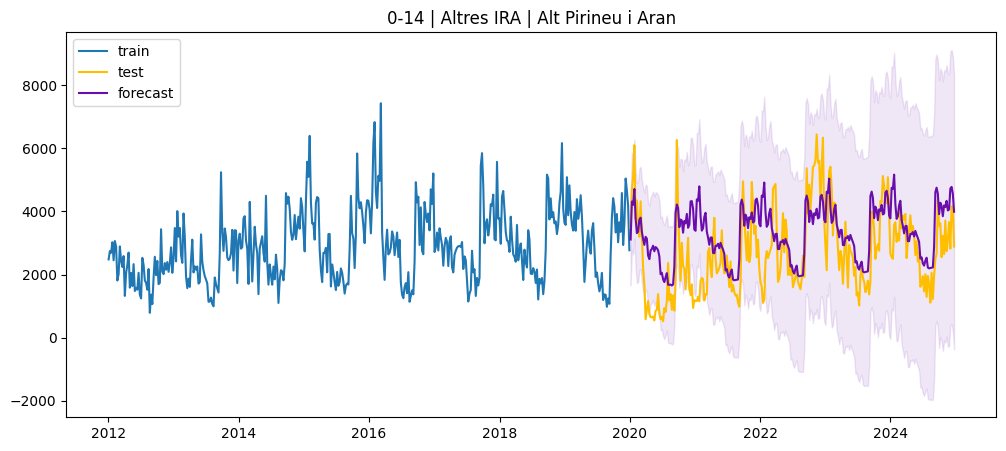

In [8]:
row, pred_df, plot_data = run_one(df, "0-14", "Altres IRA", "Alt Pirineu i Aran")


plot_pred(
    plot_data["train"],
    plot_data["test"],
    plot_data["pred"],
    plot_data["low"],
    plot_data["up"],
    title="0-14 | Altres IRA | Alt Pirineu i Aran"
)

## Automatització completa sobre les 180 sèries

Un cop validat el pipeline amb un únic exemple, s’aplica al conjunt complet de les 180 combinacions.

El bucle processa cada sèrie una per una i desa:

- una fila resum amb el model seleccionat i les mètriques d’avaluació,
- i una taula auxiliar amb les prediccions setmanals del període de test.

L’objectiu d’aquest pas és obtenir una visió global i reproduïble del comportament de l’enfocament SARIMA sobre el conjunt complet de dades.

In [9]:
rows = []
preds = []

for i, (age, diag, region) in enumerate(combinacions, start=1):    
    print(f"{i}/180 - {age} | {diag} | {region}")
    try:
        row, pred_df, _ = run_one(df, age, diag, region)
        rows.append(row)

        if pred_df is not None:
            preds.append(pred_df)

    except Exception as e:
        rows.append({
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": str(e)
        })

1/180 - 0-14 | Altres IRA | Alt Pirineu i Aran
2/180 - 0-14 | Altres IRA | Barcelona Ciutat
3/180 - 0-14 | Altres IRA | Barcelona Metropolitana Nord
4/180 - 0-14 | Altres IRA | Barcelona Metropolitana Sud
5/180 - 0-14 | Altres IRA | Camp de Tarragona
6/180 - 0-14 | Altres IRA | Catalunya Central
7/180 - 0-14 | Altres IRA | Girona
8/180 - 0-14 | Altres IRA | Lleida
9/180 - 0-14 | Altres IRA | PenedÃ¨s
10/180 - 0-14 | Altres IRA | Terres de l'Ebre
11/180 - 0-14 | Bronquiolitis | Alt Pirineu i Aran
12/180 - 0-14 | Bronquiolitis | Barcelona Ciutat
13/180 - 0-14 | Bronquiolitis | Barcelona Metropolitana Nord
14/180 - 0-14 | Bronquiolitis | Barcelona Metropolitana Sud
15/180 - 0-14 | Bronquiolitis | Camp de Tarragona
16/180 - 0-14 | Bronquiolitis | Catalunya Central
17/180 - 0-14 | Bronquiolitis | Girona
18/180 - 0-14 | Bronquiolitis | Lleida
19/180 - 0-14 | Bronquiolitis | PenedÃ¨s
20/180 - 0-14 | Bronquiolitis | Terres de l'Ebre
21/180 - 0-14 | COVID-19 | Alt Pirineu i Aran
22/180 - 0-14 |

/Users/asierlanda/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/stattools.py:2182: RuntimeWarning: invalid value encountered in scalar divide
  s_hat = s1 / s0


28/180 - 0-14 | COVID-19 | Lleida
29/180 - 0-14 | COVID-19 | PenedÃ¨s


/Users/asierlanda/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/stattools.py:2182: RuntimeWarning: invalid value encountered in scalar divide
  s_hat = s1 / s0


30/180 - 0-14 | COVID-19 | Terres de l'Ebre
31/180 - 0-14 | Escarlatina | Alt Pirineu i Aran
32/180 - 0-14 | Escarlatina | Barcelona Ciutat
33/180 - 0-14 | Escarlatina | Barcelona Metropolitana Nord
34/180 - 0-14 | Escarlatina | Barcelona Metropolitana Sud
35/180 - 0-14 | Escarlatina | Camp de Tarragona
36/180 - 0-14 | Escarlatina | Catalunya Central
37/180 - 0-14 | Escarlatina | Girona
38/180 - 0-14 | Escarlatina | Lleida
39/180 - 0-14 | Escarlatina | PenedÃ¨s
40/180 - 0-14 | Escarlatina | Terres de l'Ebre
41/180 - 0-14 | Faringoamigdalitis | Alt Pirineu i Aran
42/180 - 0-14 | Faringoamigdalitis | Barcelona Ciutat
43/180 - 0-14 | Faringoamigdalitis | Barcelona Metropolitana Nord
44/180 - 0-14 | Faringoamigdalitis | Barcelona Metropolitana Sud
45/180 - 0-14 | Faringoamigdalitis | Camp de Tarragona
46/180 - 0-14 | Faringoamigdalitis | Catalunya Central
47/180 - 0-14 | Faringoamigdalitis | Girona
48/180 - 0-14 | Faringoamigdalitis | Lleida
49/180 - 0-14 | Faringoamigdalitis | PenedÃ¨s
50

/Users/asierlanda/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/stattools.py:2182: RuntimeWarning: invalid value encountered in scalar divide
  s_hat = s1 / s0


117/180 - 15+ | COVID-19 | Girona
118/180 - 15+ | COVID-19 | Lleida
119/180 - 15+ | COVID-19 | PenedÃ¨s
120/180 - 15+ | COVID-19 | Terres de l'Ebre


/Users/asierlanda/Library/Python/3.14/lib/python/site-packages/statsmodels/tsa/stattools.py:2182: RuntimeWarning: invalid value encountered in scalar divide
  s_hat = s1 / s0


121/180 - 15+ | Escarlatina | Alt Pirineu i Aran
122/180 - 15+ | Escarlatina | Barcelona Ciutat
123/180 - 15+ | Escarlatina | Barcelona Metropolitana Nord
124/180 - 15+ | Escarlatina | Barcelona Metropolitana Sud
125/180 - 15+ | Escarlatina | Camp de Tarragona
126/180 - 15+ | Escarlatina | Catalunya Central
127/180 - 15+ | Escarlatina | Girona
128/180 - 15+ | Escarlatina | Lleida
129/180 - 15+ | Escarlatina | PenedÃ¨s
130/180 - 15+ | Escarlatina | Terres de l'Ebre
131/180 - 15+ | Faringoamigdalitis | Alt Pirineu i Aran
132/180 - 15+ | Faringoamigdalitis | Barcelona Ciutat
133/180 - 15+ | Faringoamigdalitis | Barcelona Metropolitana Nord
134/180 - 15+ | Faringoamigdalitis | Barcelona Metropolitana Sud
135/180 - 15+ | Faringoamigdalitis | Camp de Tarragona
136/180 - 15+ | Faringoamigdalitis | Catalunya Central
137/180 - 15+ | Faringoamigdalitis | Girona
138/180 - 15+ | Faringoamigdalitis | Lleida
139/180 - 15+ | Faringoamigdalitis | PenedÃ¨s
140/180 - 15+ | Faringoamigdalitis | Terres de

## Resultats finals

Al final del procés es desen dos fitxers:

- `results_sarima_v.csv`: taula resum principal, amb una fila per sèrie.
- `preds_sarima_v.csv`: taula auxiliar, amb les prediccions setmanals del període de test per a totes les sèries.

El primer fitxer és la sortida principal de l’automatització i s’utilitza posteriorment per a l’anàlisi global i la comparació de resultats.  
El segon fitxer es conserva com a material de suport, ja que permet reconstruir les prediccions i els gràfics de qualsevol sèrie individual sense haver de tornar a executar tot el procés.

In [10]:
results = pd.DataFrame(rows)
results.to_csv("results_sarima_v.csv", index=False)

if len(preds) > 0:
    preds_df = pd.concat(preds, ignore_index=True)
    preds_df.to_csv("preds_sarima_v.csv", index=False)

print("Files saved:")
print("- results_sarima_v.csv")
print("- preds_sarima_v.csv")

Files saved:
- results_sarima_v.csv
- preds_sarima_v.csv


## Últim pas

Un cop completada l’automatització, els fitxers desats es poden utilitzar per estudiar els resultats globals de l’enfocament SARIMA, incloent-hi:

- la freqüència dels models seleccionats,
- l’error de predicció,
- la cobertura total,
- la cobertura durant el període COVID,
- la cobertura en el període post-COVID,
- i els diagnòstics dels residus.

Aquest anàlisi posterior forma part de l’apartat de resultats del TFG, i no del procés d’automatització en si mateix.

In [11]:
results = pd.read_csv("results_sarima_v.csv")
results["status"].value_counts()

status
ok      174
fail      6
Name: count, dtype: int64

In [12]:
results[results["status"] == "fail"][["age", "diag", "region", "error"]].head(20)

,age,diag,region,error
20,0-14,COVID-19,Alt Pirineu i Aran,empty train or test
22,0-14,COVID-19,Barcelona Metropolitana Nord,empty train or test
23,0-14,COVID-19,Barcelona Metropolitana Sud,empty train or test
24,0-14,COVID-19,Camp de Tarragona,empty train or test
25,0-14,COVID-19,Catalunya Central,empty train or test
29,0-14,COVID-19,Terres de l'Ebre,empty train or test
